              precision    recall  f1-score   support

           0       0.97      0.72      0.82      4461
           1       0.16      0.69      0.26       339

    accuracy                           0.72      4800
   macro avg       0.56      0.71      0.54      4800
weighted avg       0.91      0.72      0.78      4800

ROC-AUC Score: 0.7712



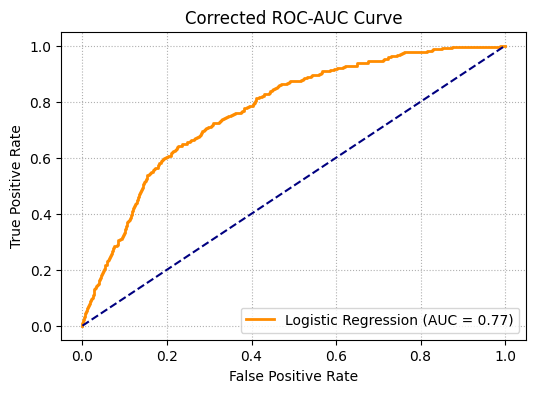

Inputs -> GDP: 1.5%, Repo: 7.5%, Unemployment: 8.5%
Output -> Probability of Default (PD): 97.23% (Absolute Risk Scale: 0.9723 out of 1.0)


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
df = pd.read_csv('macro_credit.csv')
np.random.seed(42)
portfolio_records = []
loans_per_quarter = 1000 
for _, row in df.iterrows():
    defaults = int(row['GNPA_Ratio'] * loans_per_quarter)
    good_loans = loans_per_quarter - defaults
    macro_features = [row['CRAR'], row['Loan_Growth'], row['GDP_Growth'], row['Interest_Rate'], row['Unemployment_Proxy']]
    for _ in range(defaults):
        portfolio_records.append([
            macro_features[0] + np.random.normal(0, 0.1),
            macro_features[1] + np.random.normal(0, 0.2),
            macro_features[2] + np.random.normal(0, 0.1),
            macro_features[3] + np.random.normal(0, 0.1),
            macro_features[4] + np.random.normal(0, 0.1),
            1 ])
    for _ in range(good_loans):
        portfolio_records.append([
            macro_features[0] + np.random.normal(0.1, 0.1),
            macro_features[1] + np.random.normal(-0.1, 0.2),
            macro_features[2] + np.random.normal(0.1, 0.1),
            macro_features[3] + np.random.normal(-0.1, 0.1),
            macro_features[4] + np.random.normal(-0.1, 0.1),
            0 ])
feature_cols = ['CRAR', 'Loan_Growth', 'GDP_Growth', 'Interest_Rate', 'Unemployment_Proxy']
loan_df = pd.DataFrame(portfolio_records, columns=feature_cols + ['Default'])
X = loan_df[feature_cols]
y = loan_df['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', random_state=42)
)
model_pipeline.fit(X_train, y_train)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}\n")
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Corrected ROC-AUC Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':')
plt.show()
def run_scorecard(crar, loan_growth, gdp_growth, interest_rate, unemployment):
    query = pd.DataFrame([[crar, loan_growth, gdp_growth, interest_rate, unemployment]], columns=feature_cols)
    raw_probability = model_pipeline.predict_proba(query)[0][1]
    print(f"Inputs -> GDP: {gdp_growth}%, Repo: {interest_rate}%, Unemployment: {unemployment}%")
    print(f"Output -> Probability of Default (PD): {raw_probability * 100:.2f}% (Absolute Risk Scale: {raw_probability:.4f} out of 1.0)")
    return raw_probability


SCRD_ = run_scorecard(crar=12.5, loan_growth=3.0, gdp_growth=1.5, interest_rate=7.5, unemployment=8.5)